# Eksperimen Machine Learning - Klasifikasi Poker Hand

**Nama:** ASEP HARYANA SAPUTRA  
**Dataset:** Poker Hand - UCI Machine Learning Repository  


## Perkenalan Dataset

**Sumber Dataset:**

> URL: https://archive.ics.uci.edu/dataset/158/poker+hand

**Deskripsi Dataset:**

Dataset **Poker Hand** (UCI ML Repository) terdiri dari **1.025.010 instance** yang merepresentasikan kombinasi 5 kartu remi (poker hand). Setiap instance memiliki 10 fitur input dan 1 label kelas:

- **S1-S5** (Suit tiap kartu; nilai 1=Hearts, 2=Spades, 3=Diamonds, 4=Clubs) - fitur **kategorikal**
- **C1-C5** (Rank tiap kartu; nilai integer 1-13) - fitur **ordinala**
- **CLASS** (label target): 10 kelas tangan poker (0=Nothing, 1=One Pair, ..., 9=Royal Flush)

**Tantangan Utama:** Dataset memiliki **class imbalance ekstrem** - kelas `Nothing` mendominasi (~50%), sementara `Royal Flush` hanya muncul 12 kali (<0.001%). Ini membutuhkan strategi khusus seperti SMOTE untuk training yang fair.


## Rumusan Masalah & Tujuan Eksperimen

**Rumusan Masalah:**

Bagaimana membangun model machine learning yang mampu mengklasifikasikan 10 kelas tangan poker dengan performa tinggi (F1-Score > 0.70), meskipun dihadapkan pada distribusi kelas yang sangat tidak seimbang?

**Metode:**

1. **Preprocessing:** One-Hot Encoding untuk fitur Suit (kategorikal), StandardScaler untuk Rank (ordinal), Feature Engineering (derived: flush indicator, n_unique_suits, n_unique_ranks, rank_range)
2. **Penanganan Imbalance:** SMOTE pada training set (k_neighbors=3)
3. **Model:** RandomForestClassifier dengan class_weight="balanced"

**Metrik Evaluasi:**

- Accuracy, F1-Score (weighted & macro), Precision, Recall
- Confusion Matrix untuk analisis per-kelas

---

## 1️⃣ Import Library

In [5]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE
from collections import Counter

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2️⃣ Data Loading

In [6]:
# Column definitions berdasarkan poker-hand.names
COLUMNS = [
    'S1', 'C1',  # Suit & Rank card 1
    'S2', 'C2',  # Suit & Rank card 2
    'S3', 'C3',  # Suit & Rank card 3
    'S4', 'C4',  # Suit & Rank card 4
    'S5', 'C5',  # Suit & Rank card 5
    'CLASS'      # Target: Poker Hand (0-9)
]

CLASS_NAMES = {
    0: 'Nothing',
    1: 'One Pair',
    2: 'Two Pairs',
    3: 'Three of a Kind',
    4: 'Straight',
    5: 'Flush',
    6: 'Full House',
    7: 'Four of a Kind',
    8: 'Straight Flush',
    9: 'Royal Flush'
}

RAW_DIR = './pokerhand_raw'

# Load training set
df_train = pd.read_csv(
    os.path.join(RAW_DIR, 'poker-hand-training-true.data'),
    header=None,
    names=COLUMNS
)

# Sample 100k rows dari testing set untuk validasi EDA (full set = 1M rows)
df_test_sample = pd.read_csv(
    os.path.join(RAW_DIR, 'poker-hand-testing.data'),
    header=None,
    names=COLUMNS,
    nrows=100_000
)

print(f'Training shape: {df_train.shape}')
print(f'Test sample shape: {df_test_sample.shape}')

Training shape: (25010, 11)
Test sample shape: (100000, 11)


In [7]:
# Head
df_train.head(10)

,S1,C1,S2,C2,S3,C3,S4,C4,S5,C5,CLASS
0,1,10,1,11,1,13,1,12,1,1,9
1,2,11,2,13,2,10,2,12,2,1,9
2,3,12,3,11,3,13,3,10,3,1,9
3,4,10,4,11,4,1,4,13,4,12,9
4,4,1,4,13,4,12,4,11,4,10,9
5,1,2,1,4,1,5,1,3,1,6,8
6,1,9,1,12,1,10,1,11,1,13,8
7,2,1,2,2,2,3,2,4,2,5,8
8,3,5,3,6,3,9,3,7,3,8,8
9,4,1,4,4,4,2,4,3,4,5,8


In [8]:
# Info
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 25010 entries, 0 to 25009
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   S1      25010 non-null  int64
 1   C1      25010 non-null  int64
 2   S2      25010 non-null  int64
 3   C2      25010 non-null  int64
 4   S3      25010 non-null  int64
 5   C3      25010 non-null  int64
 6   S4      25010 non-null  int64
 7   C4      25010 non-null  int64
 8   S5      25010 non-null  int64
 9   C5      25010 non-null  int64
 10  CLASS   25010 non-null  int64
dtypes: int64(11)
memory usage: 2.1 MB


In [9]:
# Descriptive statistics
df_train.describe()

,S1,C1,S2,C2,S3,C3,S4,C4,S5,C5,CLASS
count,25010.000000,25010.000000,25010.000000,25010.000000,25010.000000,25010.000000,25010.000000,25010.000000,25010.000000,25010.000000,25010.000000
mean,2.508756,6.995242,2.497721,7.014194,2.510236,7.014154,2.495922,6.942463,2.497321,6.962735,0.621152
std,1.116483,3.749805,1.121767,3.766974,1.123148,3.744974,1.116009,3.747147,1.118732,3.741579,0.788361
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000
25%,2.000000,4.000000,1.000000,4.000000,2.000000,4.000000,1.000000,4.000000,1.000000,4.000000,0.000000
50%,3.000000,7.000000,2.000000,7.000000,3.000000,7.000000,2.000000,7.000000,3.000000,7.000000,1.000000
75%,4.000000,10.000000,4.000000,10.000000,4.000000,10.000000,3.000000,10.000000,3.000000,10.000000,1.000000
max,4.000000,13.000000,4.000000,13.000000,4.000000,13.000000,4.000000,13.000000,4.000000,13.000000,9.000000


In [10]:
# ============================
# Cek Missing Values
# ============================
missing = df_train.isnull().sum()
print('Missing values per column:')
print(missing)
print(f'\nTotal missing: {missing.sum()}')

Missing values per column:
S1       0
C1       0
S2       0
C2       0
S3       0
C3       0
S4       0
C4       0
S5       0
C5       0
CLASS    0
dtype: int64

Total missing: 0


In [11]:
# ============================
# Cek Duplicate
# ============================
n_dup = df_train.duplicated().sum()
print(f'Duplicate rows: {n_dup}')
print(f'Percentage: {n_dup / len(df_train) * 100:.2f}%')

Duplicate rows: 2
Percentage: 0.01%


## 3️⃣ Exploratory Data Analysis (EDA)

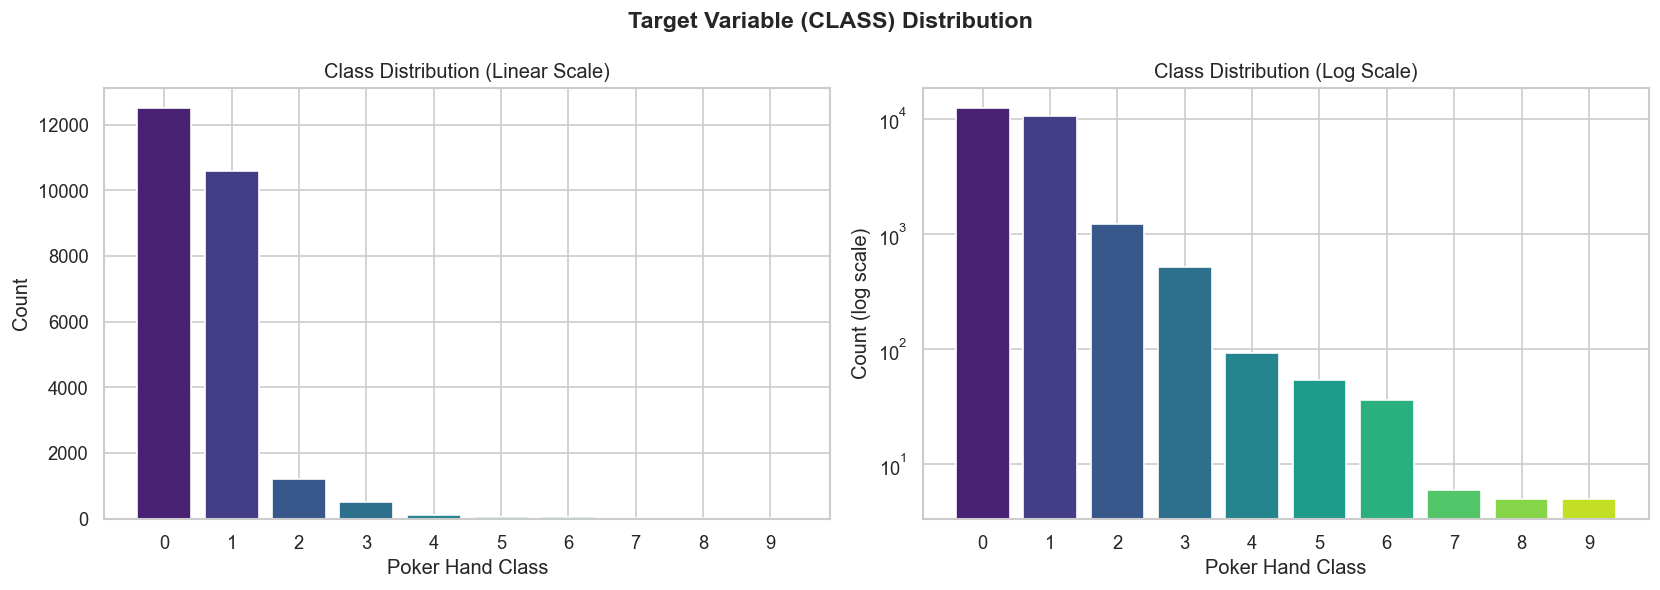


Class counts:
  Class 0 (Nothing): 12493 (49.95%)
  Class 1 (One Pair): 10599 (42.38%)
  Class 2 (Two Pairs): 1206 (4.82%)
  Class 3 (Three of a Kind): 513 (2.05%)
  Class 4 (Straight): 93 (0.37%)
  Class 5 (Flush): 54 (0.22%)
  Class 6 (Full House): 36 (0.14%)
  Class 7 (Four of a Kind): 6 (0.02%)
  Class 8 (Straight Flush): 5 (0.02%)
  Class 9 (Royal Flush): 5 (0.02%)


In [12]:
# ============================
# 3.1 Class Distribution
# ============================
class_counts = df_train['CLASS'].value_counts().sort_index()
class_labels = [f'{k}: {CLASS_NAMES[k]}' for k in class_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
axes[0].bar(class_counts.index, class_counts.values, color=sns.color_palette('viridis', 10))
axes[0].set_xlabel('Poker Hand Class')
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution (Linear Scale)')
axes[0].set_xticks(range(10))

# Log scale — reveals rare classes
axes[1].bar(class_counts.index, class_counts.values, color=sns.color_palette('viridis', 10))
axes[1].set_yscale('log')
axes[1].set_xlabel('Poker Hand Class')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Class Distribution (Log Scale)')
axes[1].set_xticks(range(10))

plt.suptitle('Target Variable (CLASS) Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nClass counts:')
for k, v in class_counts.items():
    print(f'  Class {k} ({CLASS_NAMES[k]}): {v} ({v/len(df_train)*100:.2f}%)')

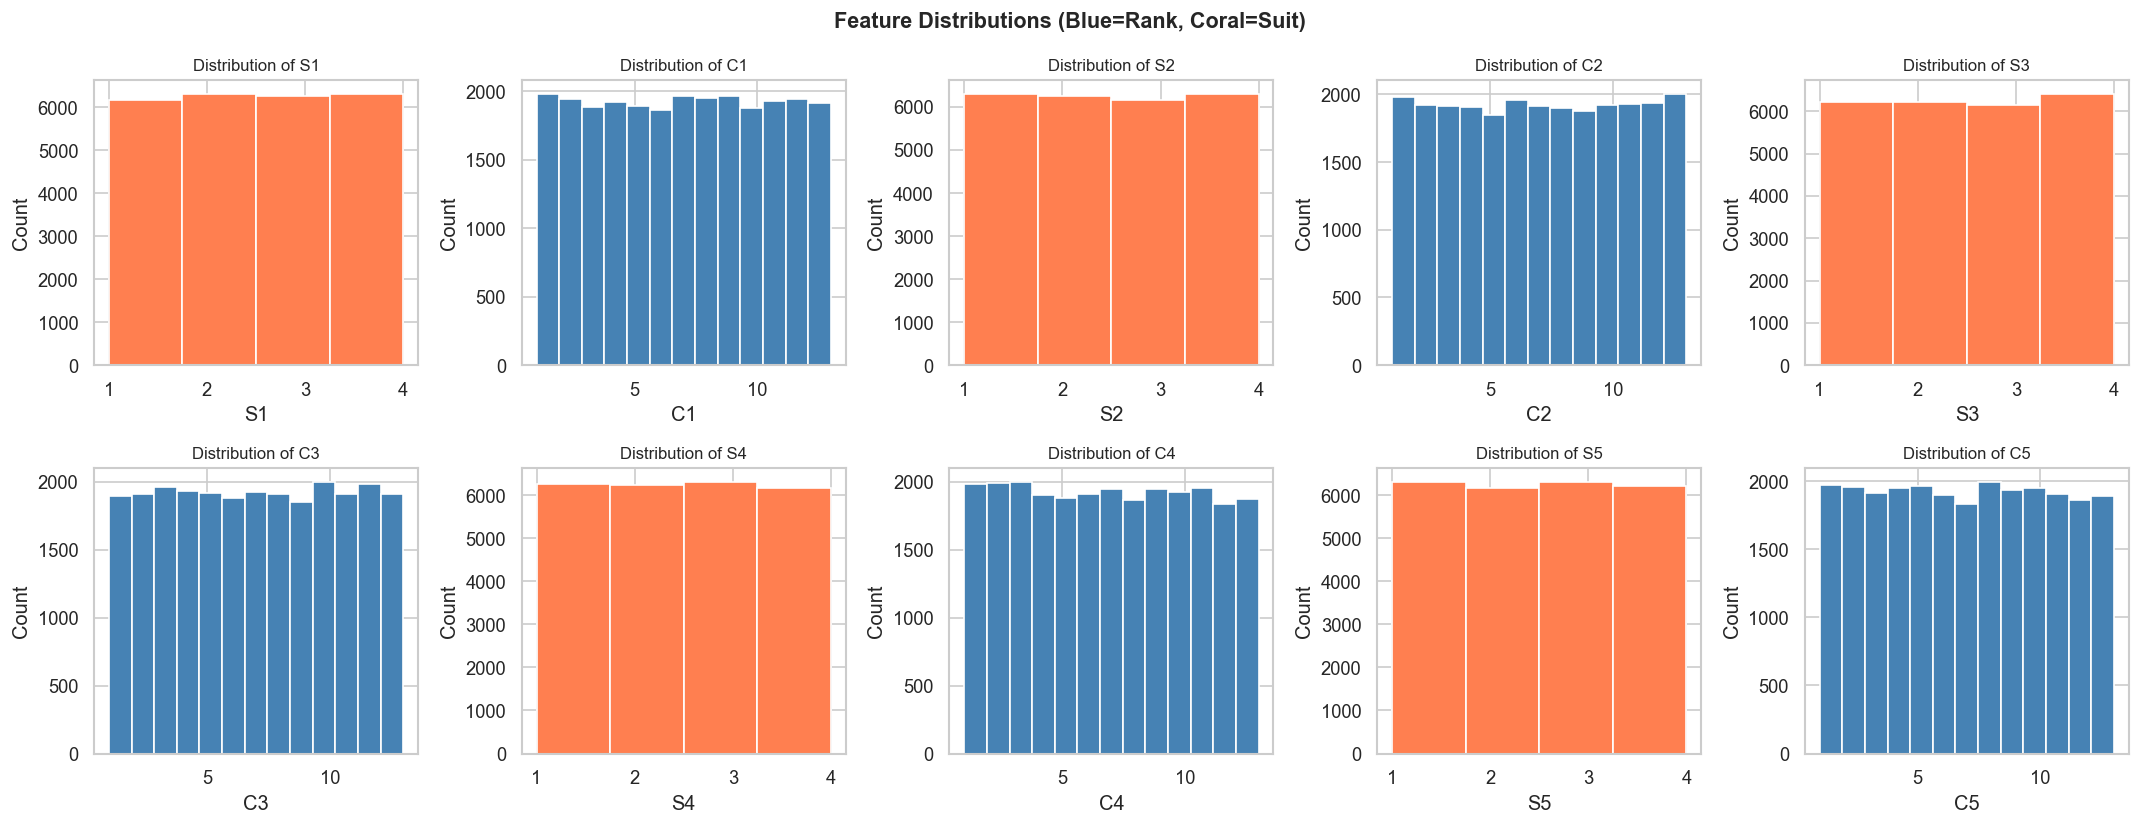

In [13]:
# ============================
# 3.2 Distribusi Fitur Numerik
# ============================
feature_cols = [c for c in COLUMNS if c != 'CLASS']
suit_cols = ['S1', 'S2', 'S3', 'S4', 'S5']
rank_cols = ['C1', 'C2', 'C3', 'C4', 'C5']

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df_train[col], bins=df_train[col].nunique(), edgecolor='white', 
                 color='steelblue' if col.startswith('C') else 'coral')
    axes[i].set_title(f'Distribution of {col}', fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distributions (Blue=Rank, Coral=Suit)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

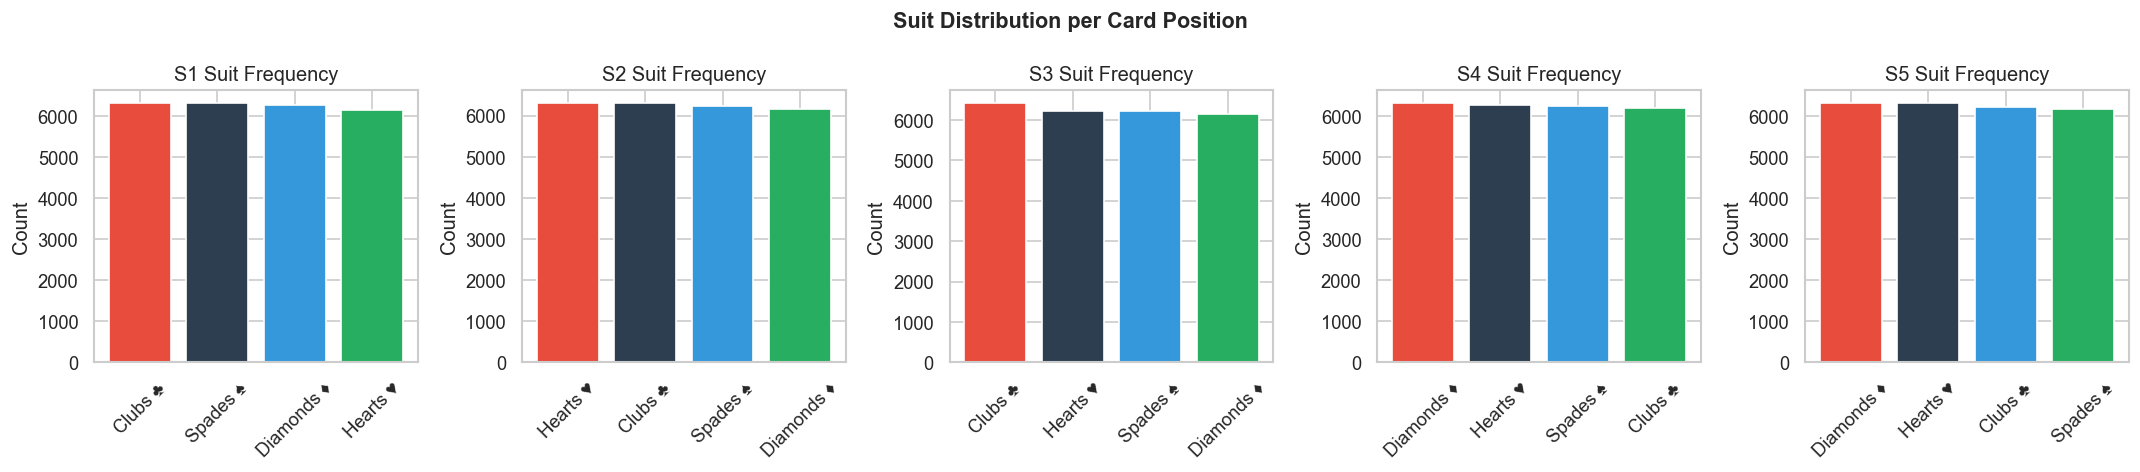

In [14]:
# ============================
# 3.3 Analisis Fitur Kategorikal (Suit)
# Suit values: 1=Hearts, 2=Spades, 3=Diamonds, 4=Clubs
# ============================
suit_map = {1: 'Hearts ♥', 2: 'Spades ♠', 3: 'Diamonds ♦', 4: 'Clubs ♣'}

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, col in enumerate(suit_cols):
    counts = df_train[col].map(suit_map).value_counts()
    axes[i].bar(counts.index, counts.values, color=['#e74c3c', '#2c3e50', '#3498db', '#27ae60'])
    axes[i].set_title(f'{col} Suit Frequency')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Count')

plt.suptitle('Suit Distribution per Card Position', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

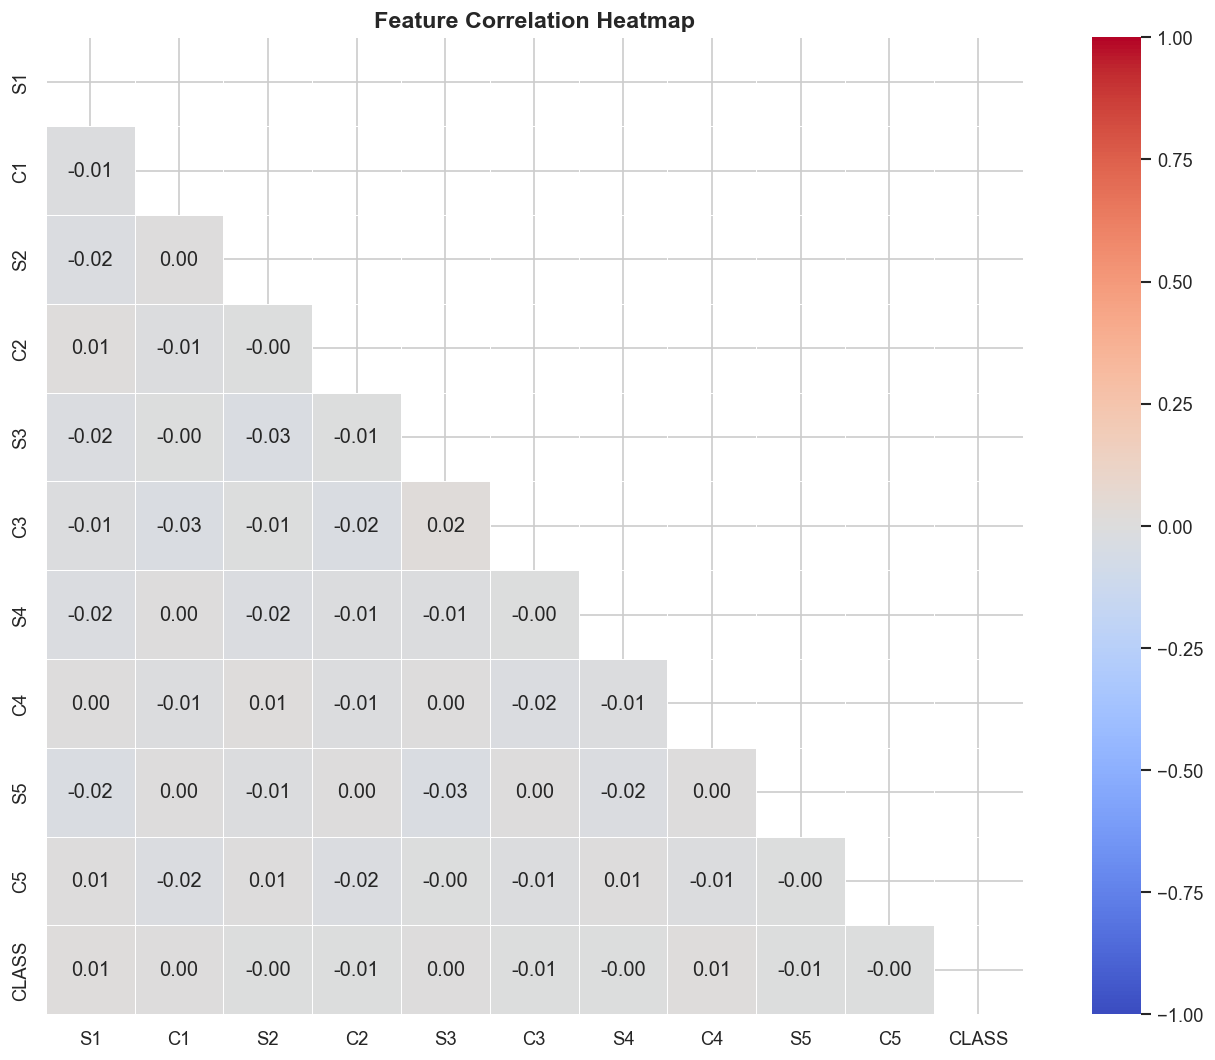

In [15]:
# ============================
# 3.4 Heatmap Korelasi
# ============================
plt.figure(figsize=(12, 9))
corr = df_train.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True,
    vmin=-1, vmax=1
)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

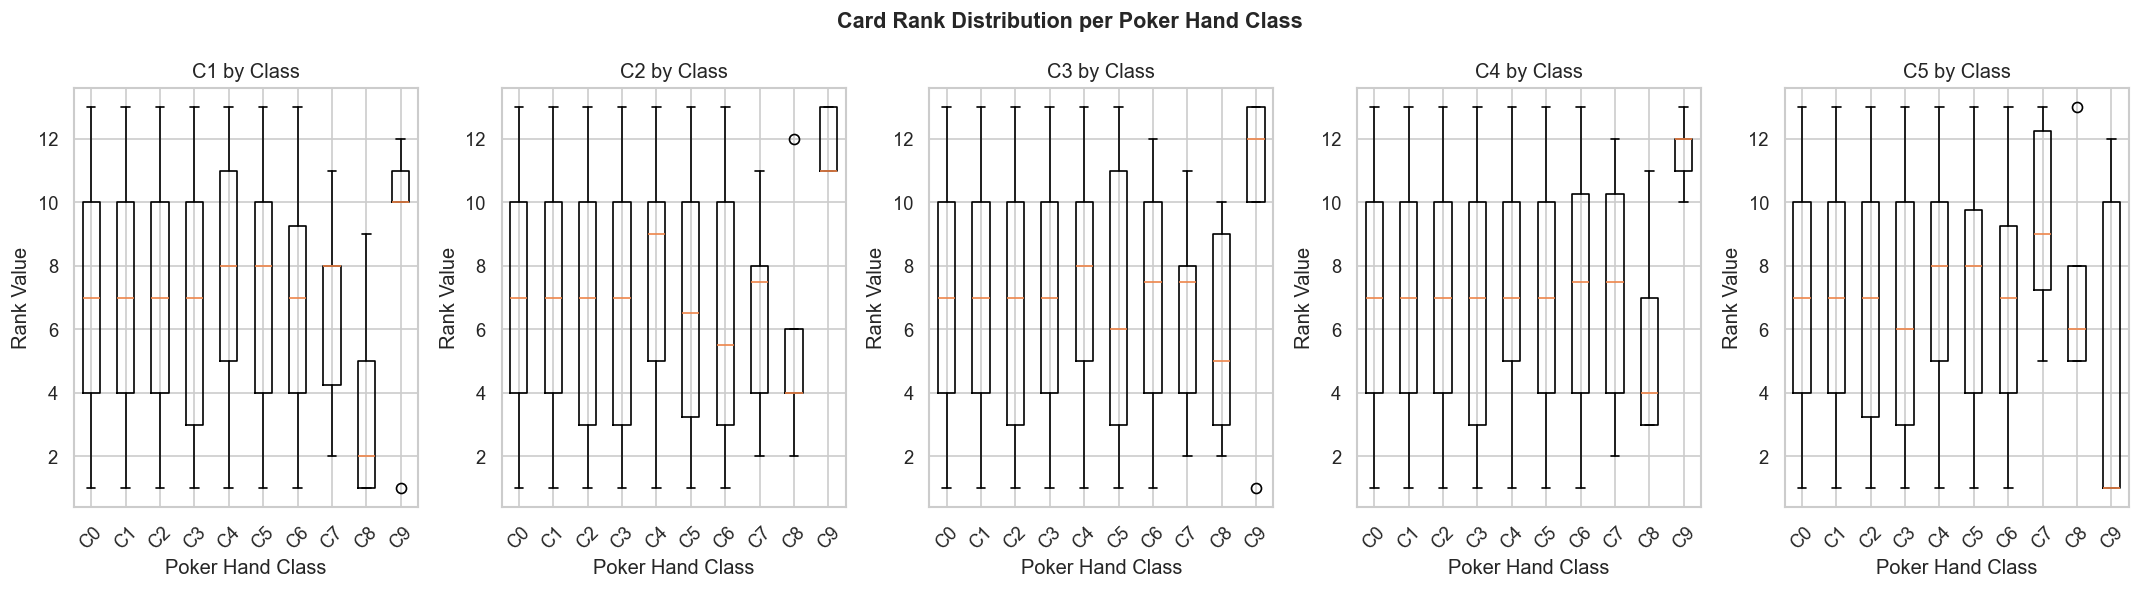

In [16]:
# ============================
# 3.5 Boxplot Rank per Class
# ============================
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, col in enumerate(rank_cols):
    # Sample untuk kecepatan plotting
    sample = df_train.sample(min(5000, len(df_train)), random_state=42)
    class_order = sorted(df_train['CLASS'].unique())
    sample['CLASS_NAME'] = sample['CLASS'].map(lambda x: f'C{x}')
    axes[i].boxplot(
        [df_train.loc[df_train['CLASS'] == c, col].values for c in class_order],
        labels=[f'C{c}' for c in class_order]
    )
    axes[i].set_title(f'{col} by Class')
    axes[i].set_xlabel('Poker Hand Class')
    axes[i].set_ylabel('Rank Value')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Card Rank Distribution per Poker Hand Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
# ============================
# 3.6 Outlier Analysis
# ============================
# Semua fitur punya range terbatas (Suit: 1-4, Rank: 1-13)
# Outlier secara statistik tidak possible di luar range ini.
# Namun kita cek IQR untuk distribusi rank.
print('IQR-based outlier check untuk Rank columns:')
for col in rank_cols:
    Q1 = df_train[col].quantile(0.25)
    Q3 = df_train[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_train[(df_train[col] < lower) | (df_train[col] > upper)]
    print(f'  {col}: Q1={Q1}, Q3={Q3}, IQR={IQR:.2f}, '
          f'bounds=[{lower:.2f}, {upper:.2f}], outliers={len(outliers)}')

IQR-based outlier check untuk Rank columns:
  C1: Q1=4.0, Q3=10.0, IQR=6.00, bounds=[-5.00, 19.00], outliers=0
  C2: Q1=4.0, Q3=10.0, IQR=6.00, bounds=[-5.00, 19.00], outliers=0
  C3: Q1=4.0, Q3=10.0, IQR=6.00, bounds=[-5.00, 19.00], outliers=0
  C4: Q1=4.0, Q3=10.0, IQR=6.00, bounds=[-5.00, 19.00], outliers=0
  C5: Q1=4.0, Q3=10.0, IQR=6.00, bounds=[-5.00, 19.00], outliers=0


In [18]:
# ============================
# 3.7 Feature Engineering Insight
# Derived features yang relevan untuk poker
# ============================
def compute_derived_features(df):
    d = df.copy()
    # Apakah semua suit sama? (indikasi Flush)
    d['all_same_suit'] = (d[['S1','S2','S3','S4','S5']].nunique(axis=1) == 1).astype(int)
    # Jumlah suit unik
    d['n_unique_suits'] = d[['S1','S2','S3','S4','S5']].nunique(axis=1)
    # Jumlah rank unik
    d['n_unique_ranks'] = d[['C1','C2','C3','C4','C5']].nunique(axis=1)
    # Max rank - Min rank (rentang rank)
    d['rank_range'] = d[['C1','C2','C3','C4','C5']].max(axis=1) - d[['C1','C2','C3','C4','C5']].min(axis=1)
    return d

df_derived = compute_derived_features(df_train)
derived_cols = ['all_same_suit', 'n_unique_suits', 'n_unique_ranks', 'rank_range']

# Korelasi derived features dengan CLASS
print('Korelasi derived features dengan CLASS:')
print(df_derived[derived_cols + ['CLASS']].corr()['CLASS'].sort_values(ascending=False))

Korelasi derived features dengan CLASS:
CLASS             1.000000
all_same_suit     0.316478
n_unique_suits    0.062415
rank_range       -0.298695
n_unique_ranks   -0.847532
Name: CLASS, dtype: float64


## 4️⃣ Data Preprocessing

In [19]:
# ============================
# 4.1 Handle Missing Values
# ============================
# Berdasarkan EDA: dataset ini TIDAK memiliki missing values.
# Namun kita tetap validasi dan log.
assert df_train.isnull().sum().sum() == 0, 'Unexpected missing values found!'
print('✅ No missing values — no imputation needed.')

✅ No missing values — no imputation needed.


In [20]:
# ============================
# 4.2 Handle Duplicates
# ============================
n_before = len(df_train)
df_clean = df_train.drop_duplicates().copy()
n_after = len(df_clean)
print(f'Rows before dedup: {n_before}')
print(f'Rows after dedup : {n_after}')
print(f'Removed          : {n_before - n_after} duplicates')

Rows before dedup: 25010
Rows after dedup : 25008
Removed          : 2 duplicates


In [21]:
# ============================
# 4.3 Feature Engineering
# ============================
df_feat = compute_derived_features(df_clean)
print('Dataset shape setelah feature engineering:', df_feat.shape)
df_feat[derived_cols + ['CLASS']].head()

Dataset shape setelah feature engineering: (25008, 15)


,all_same_suit,n_unique_suits,n_unique_ranks,rank_range,CLASS
0,1,1,5,12,9
1,1,1,5,12,9
2,1,1,5,12,9
3,1,1,5,12,9
4,1,1,5,12,9


In [22]:
# ============================
# 4.4 Encoding Fitur Kategorikal (Suit)
# Suit bukan ordinal sebenarnya (Hearts ≠ < Spades),
# oleh karena itu kita One-Hot encode.
# ============================

# Pisahkan fitur dan target
X = df_feat.drop(columns=['CLASS'])
y = df_feat['CLASS']

# Definisi kolom berdasarkan jenis
suit_cols   = ['S1', 'S2', 'S3', 'S4', 'S5']
rank_cols   = ['C1', 'C2', 'C3', 'C4', 'C5']
derived_cols_list = ['all_same_suit', 'n_unique_suits', 'n_unique_ranks', 'rank_range']

# ColumnTransformer: OHE untuk suit, Standard Scaler untuk rank (dan derived numerics)
preprocessor = ColumnTransformer(
    transformers=[
        ('suit_ohe', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), suit_cols),
        ('rank_scale', StandardScaler(), rank_cols + derived_cols_list),
    ],
    remainder='drop'
)

print('Preprocessor configured successfully.')
print(f'Input features: {X.shape[1]}')

Preprocessor configured successfully.
Input features: 14


In [23]:
# ============================
# 4.5 Train-Test Split
# 80/20 split dengan stratification untuk menjaga distribusi kelas
# ============================
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'X_train shape: {X_train_raw.shape}')
print(f'X_test shape : {X_test_raw.shape}')
print(f'y_train distribution:')
print(y_train.value_counts().sort_index())

X_train shape: (20006, 14)
X_test shape : (5002, 14)
y_train distribution:
CLASS
0    9994
1    8478
2     965
3     410
4      74
5      43
6      29
7       5
8       4
9       4
Name: count, dtype: int64


In [24]:
# ============================
# 4.6 Fit & Transform
# ============================
X_train_enc = preprocessor.fit_transform(X_train_raw)
X_test_enc  = preprocessor.transform(X_test_raw)

# Buat nama kolom output
ohe_feature_names = preprocessor.named_transformers_['suit_ohe'].get_feature_names_out(suit_cols).tolist()
scale_feature_names = rank_cols + derived_cols_list
all_feature_names = ohe_feature_names + scale_feature_names

print(f'X_train_enc shape: {X_train_enc.shape}')
print(f'X_test_enc shape : {X_test_enc.shape}')
print(f'Feature names ({len(all_feature_names)}): {all_feature_names}')

X_train_enc shape: (20006, 29)
X_test_enc shape : (5002, 29)
Feature names (29): ['S1_1', 'S1_2', 'S1_3', 'S1_4', 'S2_1', 'S2_2', 'S2_3', 'S2_4', 'S3_1', 'S3_2', 'S3_3', 'S3_4', 'S4_1', 'S4_2', 'S4_3', 'S4_4', 'S5_1', 'S5_2', 'S5_3', 'S5_4', 'C1', 'C2', 'C3', 'C4', 'C5', 'all_same_suit', 'n_unique_suits', 'n_unique_ranks', 'rank_range']


In [25]:
# ============================
# 4.7 SMOTE — Handle Class Imbalance
# SMOTE hanya diaplikasikan pada training set!
# ============================
print('Class distribution BEFORE SMOTE:')
print(Counter(y_train))

smote = SMOTE(random_state=42, k_neighbors=3)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_enc, y_train)

print('\nClass distribution AFTER SMOTE:')
print(Counter(y_train_balanced))
print(f'\nShape after SMOTE: {X_train_balanced.shape}')

Class distribution BEFORE SMOTE:
Counter({0: 9994, 1: 8478, 2: 965, 3: 410, 4: 74, 5: 43, 6: 29, 7: 5, 8: 4, 9: 4})

Class distribution AFTER SMOTE:
Counter({0: 9994, 1: 9994, 2: 9994, 3: 9994, 7: 9994, 8: 9994, 4: 9994, 9: 9994, 5: 9994, 6: 9994})

Shape after SMOTE: (99940, 29)


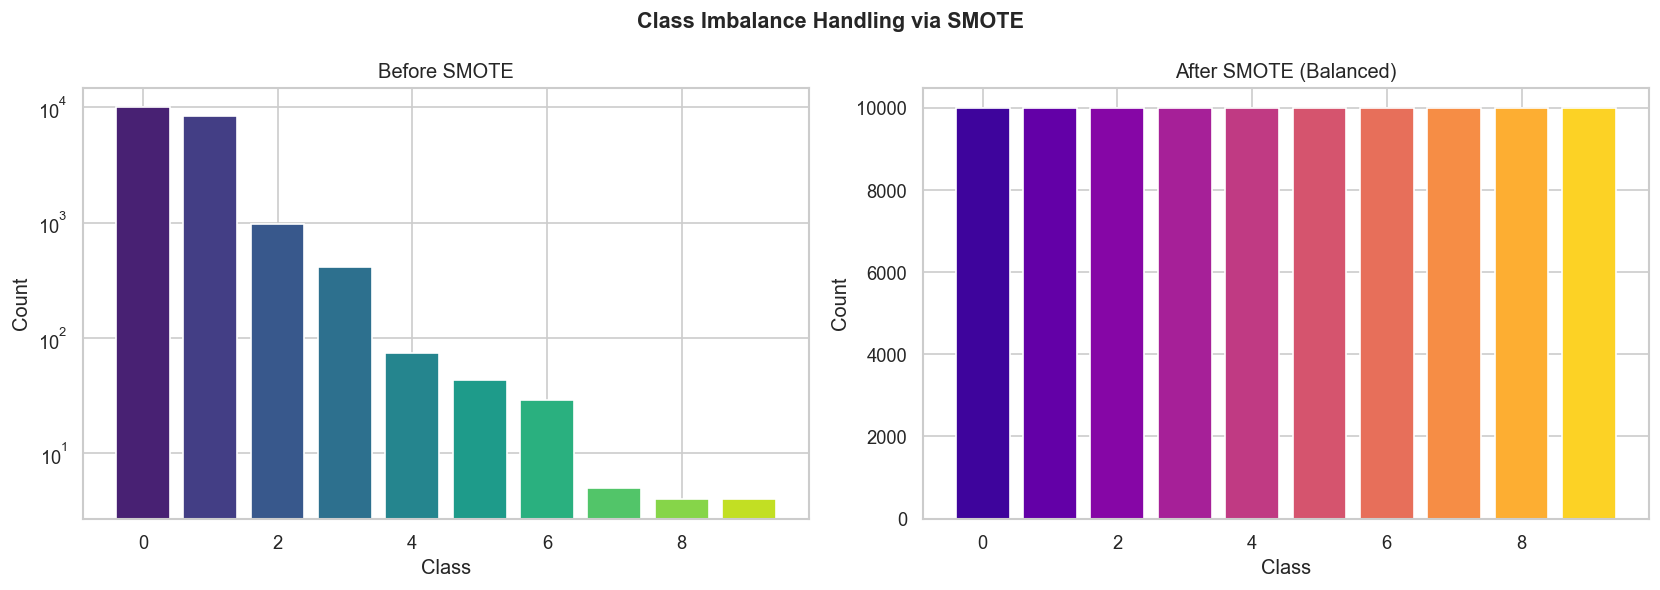

In [26]:
# Visualisasi sebelum vs sesudah SMOTE
before = Counter(y_train)
after  = Counter(y_train_balanced)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
classes = sorted(before.keys())
axes[0].bar(classes, [before[c] for c in classes], color=sns.color_palette('viridis', 10))
axes[0].set_title('Before SMOTE')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_yscale('log')

axes[1].bar(classes, [after[c] for c in classes], color=sns.color_palette('plasma', 10))
axes[1].set_title('After SMOTE (Balanced)')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Count')

plt.suptitle('Class Imbalance Handling via SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [27]:
# ============================
# 4.8 Simpan Hasil Preprocessing
# ============================
OUT_DIR = 'pokerhand_preprocessing'
os.makedirs(OUT_DIR, exist_ok=True)

# Convert ke DataFrame dengan nama kolom
df_X_train = pd.DataFrame(X_train_balanced, columns=all_feature_names)
df_X_test  = pd.DataFrame(X_test_enc,  columns=all_feature_names)
df_y_train = pd.DataFrame(y_train_balanced, columns=['CLASS'])
df_y_test  = pd.DataFrame(y_test.values, columns=['CLASS'])

df_X_train.to_csv(os.path.join(OUT_DIR, 'X_train.csv'), index=False)
df_X_test.to_csv(os.path.join(OUT_DIR, 'X_test.csv'),  index=False)
df_y_train.to_csv(os.path.join(OUT_DIR, 'y_train.csv'), index=False)
df_y_test.to_csv(os.path.join(OUT_DIR, 'y_test.csv'),  index=False)

print('✅ Preprocessed files saved to:', OUT_DIR)
for fname in os.listdir(OUT_DIR):
    fpath = os.path.join(OUT_DIR, fname)
    size  = os.path.getsize(fpath) / 1024
    print(f'  {fname}: {size:.1f} KB')

✅ Preprocessed files saved to: pokerhand_preprocessing
  X_train.csv: 31266.8 KB
  X_test.csv: 1251.3 KB
  y_train.csv: 195.2 KB
  y_test.csv: 9.8 KB


In [28]:
# Simpan juga preprocessor object untuk automasi script
import joblib
joblib.dump(preprocessor, os.path.join(OUT_DIR, 'preprocessor.joblib'))
print('✅ Preprocessor saved as preprocessor.joblib')

✅ Preprocessor saved as preprocessor.joblib


In [29]:
# Final Summary
print('='*60)
print('PREPROCESSING SUMMARY')
print('='*60)
print(f'Raw training samples  : {len(df_train)}')
print(f'After dedup           : {len(df_clean)}')
print(f'After feature eng.    : {X.shape[1]} features (was 10)')
print(f'After encoding        : {X_train_enc.shape[1]} encoded features')
print(f'X_train (after SMOTE) : {X_train_balanced.shape}')
print(f'X_test                : {X_test_enc.shape}')
print(f'Classes balanced      : {len(set(y_train_balanced))}')
print('='*60)

PREPROCESSING SUMMARY
Raw training samples  : 25010
After dedup           : 25008
After feature eng.    : 14 features (was 10)
After encoding        : 29 encoded features
X_train (after SMOTE) : (99940, 29)
X_test                : (5002, 29)
Classes balanced      : 10
